# 06. Results Summary: OOS Detection

Итоговые результаты экспериментов по Out-of-Scope детекции
на датасете CLINC150.

## Содержание
1. Setup
2. Итоговая сравнительная таблица
3. Scaling curve
4. Проверка гипотез
5. Выводы и рекомендации

## 1. Setup

In [1]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Results dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results


## 2. Итоговая сравнительная таблица

### 2.1 Few-shot (mean ± std по 3 seeds)

In [2]:
# Load all results
metrics_all = json.loads((RESULTS / "metrics.json").read_text())
df = pd.DataFrame(metrics_all)

# Models to include (in order)
models_order = [
    "autointent_classic-light",
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
    "tfidf_threshold",
]

# n_shots values
n_shots_values = [10, 20, 50]

# Build summary table: F1 OOS mean ± std
summary_rows = []
for model in models_order:
    row = {"Model": model}
    for n in n_shots_values:
        subset = df[(df["model_name"] == model) & (df["n_shots"] == n)]
        if len(subset) > 0:
            mean = subset["f1_oos"].mean()
            std = subset["f1_oos"].std() if len(subset) > 1 else 0
            row[f"{n}-shot"] = f"{mean:.3f} ± {std:.3f}" if std > 0 else f"{mean:.3f}"
        else:
            row[f"{n}-shot"] = "—"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("F1 OOS by model and n_shots (mean ± std across 3 seeds)")
print("=" * 70)
display(summary_df)

F1 OOS by model and n_shots (mean ± std across 3 seeds)


,Model,10-shot,20-shot,50-shot
0,autointent_classic-light,0.724 ± 0.022,0.819 ± 0.012,0.730 ± 0.007
1,cosine_e5large_threshold,0.660 ± 0.057,0.685 ± 0.011,0.693 ± 0.040
2,cosine_minilm_threshold,0.624 ± 0.077,0.649 ± 0.076,0.671 ± 0.012
3,tfidf_threshold,0.221 ± 0.019,0.218 ± 0.043,0.314 ± 0.077


### 2.2 Full train — детальная таблица

In [3]:
# Filter full train results for selected models
df_full = df[(df["mode"] == "full") & (df["model_name"].isin(models_order))].copy()

# Sort by model order
df_full["sort_key"] = df_full["model_name"].apply(lambda x: models_order.index(x))
df_full = df_full.sort_values("sort_key").drop(columns=["sort_key"])

# Select columns
cols = ["model_name", "oos_recall", "in_domain_acc", "f1_oos", "auroc", "latency_ms"]
full_table = df_full[cols].copy()
full_table.columns = ["Model", "OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC", "Latency (ms)"]

# Add reference row (hardcoded, marked with †)
ref_row = pd.DataFrame([{
    "Model": "AutoIntent (Golubev et al., 2025)†",
    "OOS Recall": None,
    "In-Domain Acc": 0.961,
    "F1 OOS": 0.768,
    "AUROC": None,
    "Latency (ms)": None,
}])
full_table = pd.concat([full_table, ref_row], ignore_index=True)

# Format numeric columns
for col in ["OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC"]:
    full_table[col] = full_table[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "—")
full_table["Latency (ms)"] = full_table["Latency (ms)"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")

print("Full Train Results")
print("=" * 80)
display(full_table)

Full Train Results


,Model,OOS Recall,In-Domain Acc,F1 OOS,AUROC,Latency (ms)
0,autointent_classic-light,0.835,0.940,0.841,0.974,0.19
1,cosine_e5large_threshold,0.595,0.908,0.719,0.961,19.24
2,cosine_minilm_threshold,0.494,0.875,0.642,0.963,7.12
3,tfidf_threshold,0.277,0.884,0.417,0.898,3.14
4,"AutoIntent (Golubev et al., 2025)†",—,0.961,0.768,—,—


**Примечание о сравнении с литературой.** Специализированные OOS-методы (ADB, DA-ADB, DETER) публикуют результаты на CLINC150 в протоколе TEXTOIR: варьируемая доля известных интентов (25%/50%/75%), остальные становятся OOS при тесте. В нашем протоколе все 150 интентов фиксированы, OOS — отдельный класс. Прямое сравнение чисел некорректно. Единственный напрямую сравнимый референс — AutoIntent Table 3 (тот же протокол, тот же датасет). Сравнение с ADB/DA-ADB/DETER требует отдельного эксперимента в их протоколе и выходит за рамки данной работы.

## 3. Scaling curve

In [4]:
# Models for scaling curve
scaling_models = [
    "autointent_classic-light",
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
]

# Collect data for all modes
scaling_data = []

for model in scaling_models:
    model_df = df[df["model_name"] == model]
    
    # Few-shot: mean by n_shots
    for n in [10, 20, 50]:
        subset = model_df[model_df["n_shots"] == n]
        if len(subset) > 0:
            scaling_data.append({
                "model": model,
                "mode": f"{n}-shot",
                "f1_oos_mean": subset["f1_oos"].mean(),
                "f1_oos_std": subset["f1_oos"].std() if len(subset) > 1 else 0,
            })
    
    # Full train
    full_subset = model_df[model_df["mode"] == "full"]
    if len(full_subset) > 0:
        scaling_data.append({
            "model": model,
            "mode": "full train",
            "f1_oos_mean": full_subset["f1_oos"].values[0],
            "f1_oos_std": 0,
        })

scaling_df = pd.DataFrame(scaling_data)
print(f"Scaling data points: {len(scaling_df)}")

Scaling data points: 12


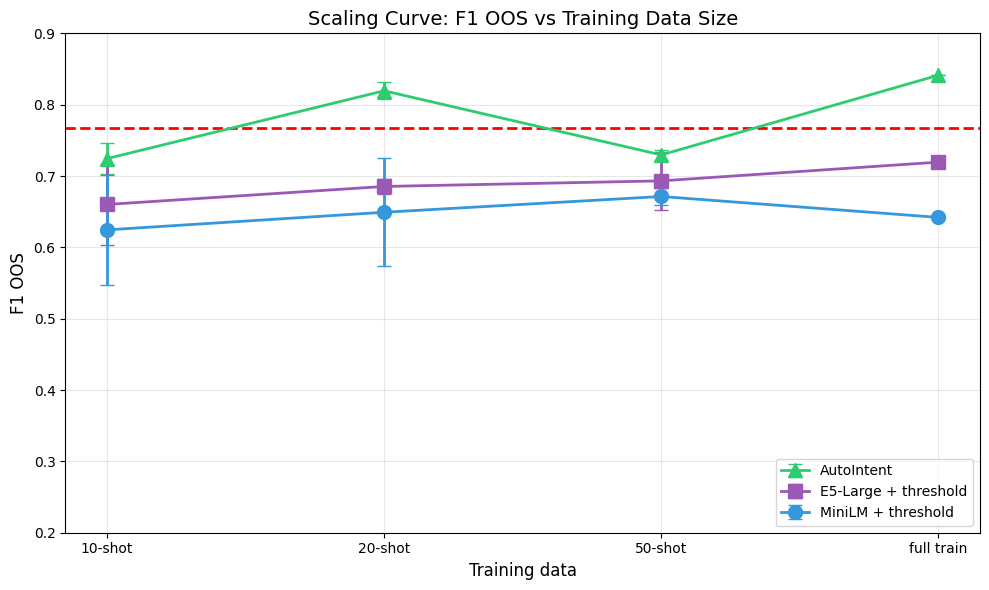

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/summary_scaling_curve.png


In [5]:
# Plot scaling curve
fig, ax = plt.subplots(figsize=(10, 6))

# X-axis labels (categorical)
x_labels = ["10-shot", "20-shot", "50-shot", "full train"]
x_pos = np.arange(len(x_labels))

# Colors and markers
styles = {
    "autointent_classic-light": {"color": "#2ecc71", "marker": "^", "label": "AutoIntent"},
    "cosine_e5large_threshold": {"color": "#9b59b6", "marker": "s", "label": "E5-Large + threshold"},
    "cosine_minilm_threshold": {"color": "#3498db", "marker": "o", "label": "MiniLM + threshold"},
}

# Plot each model
for model in scaling_models:
    model_data = scaling_df[scaling_df["model"] == model]
    
    # Get values in correct order
    y_vals = []
    y_errs = []
    for mode in x_labels:
        row = model_data[model_data["mode"] == mode]
        if len(row) > 0:
            y_vals.append(row["f1_oos_mean"].values[0])
            y_errs.append(row["f1_oos_std"].values[0])
        else:
            y_vals.append(np.nan)
            y_errs.append(0)
    
    style = styles[model]
    ax.errorbar(
        x_pos, y_vals, yerr=y_errs,
        marker=style["marker"], markersize=10,
        color=style["color"], linewidth=2, capsize=5,
        label=style["label"],
    )

# Reference line: AutoIntent Table 3
REFERENCE_F1 = 0.768
ax.axhline(y=REFERENCE_F1, color="red", linestyle="--", linewidth=2)
ax.annotate(
    "AutoIntent Table 3†",
    xy=(3.2, REFERENCE_F1), fontsize=9, color="red",
    verticalalignment="bottom",
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Training data", fontsize=12)
ax.set_ylabel("F1 OOS", fontsize=12)
ax.set_title("Scaling Curve: F1 OOS vs Training Data Size", fontsize=14)
ax.set_ylim(0.2, 0.9)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / "summary_scaling_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS / 'summary_scaling_curve.png'}")

## 4. Проверка гипотез

| # | Гипотеза | Метод | Ключевой результат | Вывод |
|---|----------|-------|-------------------|-------|
| HYP-002 | Асимметричная cost function | Постфактум threshold на val, α:β ∈ {1:1, 2:1, 5:1, 10:1}, 20-shot, 3 seeds | Recall ↑ до 0.976, но FPR ↑ до 0.247; нестабильно при 2:1 (std Acc=0.045) | ⚠️ Технически работает, trade-off невыгоден для стандартного guardrail |

Проверенная гипотеза показала, что стандартная F1-оптимизация AutoIntent уже обеспечивает хороший guardrail-баланс: Recall=0.899 при FPR=0.066 в 20-shot режиме. AutoIntent Pareto-доминирует над cosine-бейзлайнами по обеим осям одновременно. Асимметричная cost function остаётся configurable knob для сценариев с жёсткими требованиями к Recall, но не является улучшением пайплайна по умолчанию.

Дополнительно: анализ AutoML-конфигурации (секция 9 ноутбука 03) показал, что AutoIntent стабильно выбирает linear + threshold во всех 9 runs. Провал на 50-shot объясняется переобучением порога на val-фолдах (val/test gap +0.218), а не сменой архитектуры.

HYP-001 (per-intent threshold calibration) отложена: в few-shot режиме недостаточно данных на кластер для надёжной калибровки.

## 5. Выводы и рекомендации

### Главные результаты

AutoIntent classic-light применим как OOS-guardrail. В few-shot режиме (20-shot, 3 000 примеров обучающих данных) достигает F1 OOS=0.819, превосходя все cosine-бейзлайны на +13–19 п.п. На полных данных (full train) F1=0.841, что на +7.3 п.п. выше референса AutoIntent Table 3. AutoML-оптимизация стабильно выбирает linear + threshold и обеспечивает в 3–4 раза меньшую вариацию результатов по сравнению с бейзлайнами (CV ~3% vs ~9–12%).

### Ограничения

Первое: сравнение с специализированными OOS-методами (ADB, DA-ADB, DETER) невозможно без отдельного эксперимента в их протоколе — они используют другую постановку задачи. Второе: датасет DeepPavlov/clinc150 отличается от оригинального сплита CLINC150, используемого в части литературы (250 vs 100 OOS-примеров в train), что может объяснять превышение нашего full train результата над AutoIntent Table 3. Третье: latency измерена на CPU (M1), для GPU-инференса цифры будут другими.

### Рекомендации для production

Использовать AutoIntent classic-light с embedder multilingual-e5-large-instruct. Минимальный рабочий порог данных — 20 примеров на интент; именно на этом объёме достигается оптимальный баланс качества и устойчивости. При жёстких требованиях к latency переключиться на pilot-режим (e5-small, 0.2ms) с потерей ~5 п.п. F1. Threshold менять не нужно: F1-оптимизация AutoIntent уже обеспечивает хороший guardrail-баланс (FPR=0.066 при OOS Recall=0.899 в 20-shot режиме).

### Дальнейшие шаги

**Следующий спринт:** Jailbreak Detection.

**Открытые вопросы по OOS:**
- Сравнение с SOTA: изучить Papers with Code leaderboard для CLINC150 OOS Detection
- Per-intent threshold calibration (HYP-001, отложена из-за недостатка данных в few-shot)
- Сравнение в протоколе TEXTOIR для прямого соотнесения с ADB/DA-ADB/DETER